In [ ]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]
Interesting_right =   [5, 33, 45, 49]
Interesting_left =   [4, 32, 44, 48]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

data_folder="../Data/"

freq_personalized = {"subject_0":[9,14.5],
                     "subject_1":[8,12],
                     "subject_2":[8,13.5],
                     "subject_3":[4,9.5],
                     "subject_4":[18,23.5],
                     "subject_5":[4,9.5],
                     "subject_6":[4,9.5],
                     "subject_7":[4,9.5],
                     "subject_8":[4,12],
                     "subject_9":[9.5,15.5],
                     "subject_10":[9,14.5],
                     "subject_11":[4,10.5],
                     "subject_12":[8,13.5],
                     "subject_13":[4,10.],
                     "subject_14":[12,18],
                     "subject_15":[4,8],
                     "subject_16":[4,13],
                     "subject_17":[4,12],
                     "subject_18":[4,9.5],
                     "subject_19":[4,12.5],
}

from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, select_regions_Cohen_effect_size, compute_welch
from BCI_Library import saveresults_pickle, select_rows, compute_welch, extract_features_from_spectra_more_bands,cohens_d_per_columm


In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250
ROI =13
quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

DataType = "EEG"
    
subject_index = 0 

data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                kargs_welch={"fmin":8, "fmax":30},
                                #starttime=750,
                                )

cohens_d_per_columm(WMI[:,ROI],WRe[:,ROI],return_all=True)

array([-0.20022119, -0.75798945, -1.19609067, -1.13552225, -1.29018219,
       -1.00193354, -0.81433431, -0.44881227, -0.26244042, -0.09317718,
       -0.04929547, -0.07206923, -0.15276291, -0.19800524, -0.20977128,
       -0.3572777 , -0.4373532 , -0.42541345, -0.29919351, -0.23791096,
       -0.1238987 , -0.15315306, -0.14373938, -0.04892952, -0.06171731,
       -0.08563473, -0.17950148])

In [14]:
My_cohen = cohens_d_per_columm(WMI[:,ROI],WRe[:,ROI],return_all=True)

In [16]:
import pingouin
for i in range(WMI.shape[2]):
    Pingouin_cohen = pingouin.compute_effsize(WMI[:,ROI,i],WRe[:,ROI,i], paired=True, eftype='cohen')
    print(Pingouin_cohen, "\t",Pingouin_cohen - My_cohen[i])

-0.2002211916809305 	 1.3600232051658168e-15
-0.7579894478241868 	 6.661338147750939e-16
-1.196090667615546 	 -6.661338147750939e-16
-1.135522245285393 	 -8.881784197001252e-16
-1.2901821884836038 	 -8.881784197001252e-16
-1.0019335355937642 	 1.1102230246251565e-15
-0.8143343096420107 	 0.0
-0.4488122698361581 	 1.4432899320127035e-15
-0.26244041633412873 	 0.0
-0.09317718117146621 	 2.498001805406602e-16
-0.04929546567392271 	 -7.355227538141662e-16
-0.07206923283131467 	 -7.91033905045424e-16
-0.15276290963133343 	 3.3306690738754696e-16
-0.19800524389451615 	 5.551115123125783e-17
-0.20977127843363616 	 -1.609823385706477e-15
-0.3572776981682391 	 -5.551115123125783e-17
-0.43735320037863135 	 1.3322676295501878e-15
-0.42541345191137403 	 -1.5543122344752192e-15
-0.29919351444400355 	 -3.885780586188048e-16
-0.23791095650993715 	 -1.942890293094024e-16
-0.12389869513170843 	 -5.551115123125783e-17
-0.15315306099533565 	 4.163336342344337e-16
-0.14373938270380107 	 0.0
-0.04892951801

In [7]:
WMI[:,ROI].shape

(78, 27)

# TEST

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows


def plot_violin_all_subj(Dataframe_performances,  num_settings_showed,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions,
                  divisioni  ,hlines_positions=[],
                  track_subjects=True,  savepath=False):
    """
    divisioni: [0,3,6,9] - dove andrò a mettere le vlines e dove farò il track dei soggetti (linee tratteggiate tra i diversi violin)
    """
    chaanche_lvl = 0.58 # https://pubmed.ncbi.nlm.nih.gov/25596422/
    hlines_positions = hlines_positions + [chaanche_lvl]
    PerData = Dataframe_performances
    vlines_positions=[divisioni[_]-0.5 for _ in range(1,len(divisioni)-1)]
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    nps = num_settings_showed
    x_positions = np.arange(nps)

    styles=["--","solid"]
    markes=["s","o"]
    size=20

    all_perfs = []
    for subject in range(20):

        perfs_per_subject = []
        for setting in range(nps):
            # Extract performances
            tmp_dict = {"subject":subject}
            for key in dict_per_setting:
                tmp_dict[key] = dict_per_setting[key][setting]
            rows = select_rows(PerData, dict_fixed_selection | tmp_dict)
            perfs_per_subject.append(np.array(list(rows["Performance"].values)).mean())
        all_perfs.append(perfs_per_subject)
        shifcolor=1 if subject>=10 else 0
        color=f"C{subject+shifcolor}"

        ax.scatter(x_positions, perfs_per_subject, marker=markes[subject//10],s=size,color=color)#facecolors='none',edgecolors=color

        for __ in range(len(divisioni)-1):
            if not track_subjects: break
            ax.plot(x_positions[divisioni[__]:divisioni[__+1]], perfs_per_subject[0:3], linestyle=styles[subject//10], linewidth=0.7,color=color)

        
    all_perfs = np.array(all_perfs)   # shape (20 subjects, 9 settings)

    #Violin plot
    ax_violin = ax
    violins = ax_violin.violinplot(
        all_perfs,
        positions=x_positions,
        showmeans=False,
        showmedians=True,
        widths=0.8,
    )

    for part in violins['bodies']+[violins['cbars']]:
        part.set_zorder(-20)
    xlims = ax.get_xlim()
    ax_violin.set_ylabel("Performance")
    ax.hlines(hlines_positions, -1, 12, colors='grey', linestyles='dashed', label="Chance Level",zorder=-1, alpha=0.7)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_ticklabels)
    ax.vlines(vlines_positions, 0.5, 1, colors='gray', linestyles='dashed')
    ax.set_ylim(0.5, 1)
    for __ in range(len(textes)):
        ax.text(textes_x_positions[__], 0.1, textes[__], transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')

    ax.text(1., 0.192, f"Chance level  ", transform=ax.transAxes, fontsize=9, verticalalignment='top',horizontalalignment='right')
    title = f"Distribution of Performance Across Subjects for Each Setting\n"
    for key,value in dict_fixed_selection.items():
        title+= f"{key}:{value} | "
    title=title[:-2]
    ax.set_title(title, fontsize=13)
    ax.set_xlim(xlims)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.show()
    

In [25]:
import pandas as pd
PerData = pd.read_pickle("../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
PerData

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
0,"[23, 15, 14]",3.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.875, 0.8709677419354839, 0.9032258064516129...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
1,"[23, 15, 14, 22, 17]",5.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.9375, 0.8387096774193549, 0.838709677419354...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
2,"[23, 15, 14, 22, 17, 35, 42, 50, 6, 58]",10.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.9375, 0.8709677419354839, 0.870967741935483...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
3,"[23, 15, 14, 22, 17, 35, 42, 50, 6, 58, 51, 27...",20.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.96875, 0.8709677419354839, 0.90322580645161...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
4,"[67, 61, 43]",3.0,EEG,"((8, 12), (12, 30))",1.0,SVC,"[0.7368421052631579, 0.7368421052631579, 0.710...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
...,...,...,...,...,...,...,...,...,...,...,...
4495,"[[14, 44, 40], [44, 32, 62]]",3.0,EEG concat MEG,"((8, 12), (12, 30))",19.0,RandomForest,"[0.7105263157894737, 0.7894736842105263, 0.736...",PowerSpectra - MeanMax band,MyCriteria2 selection,2025-12-25,False
4496,"[[14, 44, 40, 48, 45], [44, 32, 62, 33, 4]]",5.0,EEG concat MEG,"((8, 12), (12, 30))",19.0,RandomForest,"[0.6842105263157895, 0.8421052631578947, 0.763...",PowerSpectra - MeanMax band,MyCriteria2 selection,2025-12-25,False
4497,"[[14, 44, 40, 48, 45, 59, 51, 32, 63, 58], [44...",10.0,EEG concat MEG,"((8, 12), (12, 30))",19.0,RandomForest,"[0.7105263157894737, 0.7894736842105263, 0.736...",PowerSpectra - MeanMax band,MyCriteria2 selection,2025-12-25,False
4498,"[[14, 44, 40, 48, 45, 59, 51, 32, 63, 58, 46, ...",20.0,EEG concat MEG,"((8, 12), (12, 30))",19.0,RandomForest,"[0.7105263157894737, 0.7631578947368421, 0.710...",PowerSpectra - MeanMax band,MyCriteria2 selection,2025-12-25,False


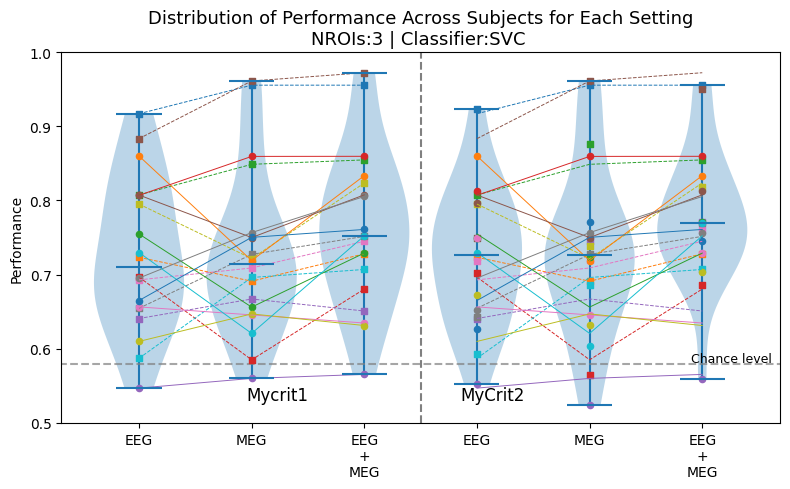

In [26]:
dict_per_setting = {"Comments":["MyCriteria selection"]*3+["MyCriteria2 selection"]*3,
                    "DataType":["EEG","MEG","EEG concat MEG"]*2}
plot_violin_all_subj(PerData,6,{"NROIs":3,"Classifier":"SVC"},dict_per_setting,["EEG","MEG","EEG\n+\nMEG"]*2,["Mycrit1","MyCrit2"],[0.3,0.6],[0,3,6])

In [ ]:
# All Subjects 

# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

chaanche_lvl = 0.58 # https://pubmed.ncbi.nlm.nih.gov/25596422/

VisualizigNROIs=20

PerData = pd.read_pickle("../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

num_performances_showed = 12
nps=num_performances_showed

x_positions = np.arange(nps)

cmap = plt.cm.get_cmap("tab20", 20)
styles=["--","solid"]
markes=["s","o"]
size=20


classifiers=["SVC"]*12
Datatypes=["MEG","EEG","EEG concat MEG"]*4
Comments=["MyCriteria selection"]*3  + ["MyCriteria2 selection"]*3  + ["T test selection mean power alpha beta"]*3 + ["Cohen's d effect size selection"]*3 #"Cohen's d effect size selection spectra starting from 3s"

x_ticklabels=[_.replace(" concat ","\n+\n") for _ in Datatypes]

all_perfs = []
dict_fixed_selection = {"Classifier":"SVC", "NROIs":VisualizigNROIs}
for subject in range(20):

    perfs_per_subject = []
    for setting in range(nps):
        # Extract performances
        rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,
                                                            "DataType":Datatypes[setting], "Comments":Comments[setting]})
        perfs_per_subject.append(np.array(list(rows["Performance"].values)).mean())
    all_perfs.append(perfs_per_subject)
    shifcolor=1 if subject>=10 else 0
    color=f"C{subject+shifcolor}"

    ax.scatter(x_positions, perfs_per_subject, marker=markes[subject//10],s=size,color=color)#facecolors='none',edgecolors=color
    ax.plot(x_positions[0:3], perfs_per_subject[0:3], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[3:6], perfs_per_subject[3:6], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[6:9], perfs_per_subject[6:9], linestyle=styles[subject//10], linewidth=0.7,color=color)
    ax.plot(x_positions[9:12], perfs_per_subject[9:12], linestyle=styles[subject//10], linewidth=0.7,color=color)
    
    
all_perfs = np.array(all_perfs)   # shape (20 subjects, 9 settings)

#Violin plot
ax_violin = ax
violins = ax_violin.violinplot(
    all_perfs,
    positions=x_positions,
    showmeans=False,
    showmedians=True,
    widths=0.8,
)

for part in violins['bodies']+[violins['cbars']]:
    part.set_zorder(-20)
xlims = ax.get_xlim()
ax_violin.set_ylabel("Performance")
ax.hlines([chaanche_lvl], -1, 12, colors='grey', linestyles='dashed', label="Chance Level",zorder=-1, alpha=0.7)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_ticklabels)
ax.vlines([2.5,5.5,8.5], 0.5, 1, colors='gray', linestyles='dashed')
ax.set_ylim(0.5, 1)
ax.text(0.15, 0.1, f"MyCriteria", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.38, 0.1, f"MyCriteria2", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.62, 0.1, f"T Test", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')
ax.text(0.88, 0.1, f"Cohen's eff. siz.", transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')

ax.text(1., 0.192, f"Chance level  ", transform=ax.transAxes, fontsize=9, verticalalignment='top',horizontalalignment='right')
ax.set_title(f"Distribution of Performance Across Subjects for Each Setting\nClassifier SVM, N of ROIs = {VisualizigNROIs}", fontsize=13)
ax.set_xlim(xlims)
plt.tight_layout()

#plt.savefig(savepathIMG+"Performance_vs_Setting_41_ROIs.png",dpi=300)
plt.show()